In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from bdshare import get_current_trade_data
from bdshare import get_basic_hist_data

In [37]:
from scipy.optimize import minimize 
import random 

In [38]:
stock_names=['ISLAMIBANK', 'BATBC', 'RENATA', 'LINDEBD', 'BERGERPBL', 'BXPHARMA',
       'SQURPHARMA', 'GP', 'OLYMPIC', 'UPGDCL', 'DELTALIFE', 'IBNSINA',
       'WALTONHIL','UNIQUEHRL', 'ADNTEL', 'ITC', 'APEXFOODS', 'FORTUNE',
       'AMANFEED','ACI', 'IFILISLMF1', 'AIBL1STIMF', 'RECKITTBEN',
       'JMISMDL']

In [39]:
end_date=datetime.today()
n_years=1
start_date=end_date-timedelta(days=40)
df=pd.DataFrame()
for i in stock_names:
    df[i]=get_basic_hist_data(str(start_date),str(end_date),i,index='date')['close']


In [40]:
returns=df.pct_change()
returns

,ISLAMIBANK,BATBC,RENATA,LINDEBD,BERGERPBL,BXPHARMA,SQURPHARMA,GP,OLYMPIC,UPGDCL,...,ADNTEL,ITC,APEXFOODS,FORTUNE,AMANFEED,ACI,IFILISLMF1,AIBL1STIMF,RECKITTBEN,JMISMDL
date,,,,,,,,,,,,,,,,,,,,,
2025-07-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-10,0.006928,-0.004230,-0.004482,0.000668,0.002237,0.020277,0.004308,-0.001001,0.027995,-0.007235,...,0.035912,-0.005305,0.035363,0.097403,-0.004016,0.041335,0.000000,0.000000,-0.000394,0.043091
2025-07-13,-0.029817,0.015221,0.000000,-0.003002,-0.000328,0.003138,0.003813,0.001336,0.007600,0.000810,...,0.018667,-0.002667,0.058824,0.011834,0.000000,0.002545,0.021277,-0.032258,0.006882,0.021368
2025-07-14,0.049645,-0.016736,0.002455,0.000781,-0.003546,-0.014599,0.003799,-0.005672,-0.011942,0.000000,...,-0.031414,-0.008021,-0.011201,0.029240,0.012097,-0.009137,0.041667,0.033333,-0.006202,-0.032078
2025-07-15,-0.020270,-0.006383,-0.003266,-0.001226,-0.004020,-0.032804,-0.000946,-0.001342,-0.005725,0.002427,...,0.009459,0.002695,0.031717,-0.017045,0.007968,0.039447,0.040000,-0.032258,-0.000424,0.024496
2025-07-16,0.000000,0.012491,0.003891,0.007922,-0.001852,0.052516,0.008996,-0.002688,0.002559,0.006457,...,0.018742,0.024194,-0.012736,0.000000,-0.007905,0.015771,-0.019231,0.000000,-0.000121,-0.001406
2025-07-17,0.000000,0.003877,0.007752,0.007085,0.010340,0.010395,-0.000469,0.011456,-0.004467,0.024860,...,-0.009198,0.000000,-0.012900,-0.017341,0.023904,-0.034449,-0.019608,0.016667,0.000182,0.050000
2025-07-20,-0.006897,0.018610,0.046356,0.020226,0.003477,0.033951,0.014554,0.009327,0.019231,0.045383,...,-0.005305,0.015748,-0.007661,-0.005882,-0.011673,0.002513,-0.020000,-0.032787,0.002910,-0.004695
2025-07-21,0.048611,0.034126,-0.000967,-0.000862,0.014514,-0.001990,-0.000925,0.023432,-0.003774,-0.025449,...,-0.012000,-0.007752,0.014532,-0.011834,-0.015748,-0.015539,-0.020408,-0.016949,-0.000332,-0.020889


In [41]:
mu=returns.mean()*252
cov=returns.cov()*252

def neg_sharpe(w):
    r=np.dot(w,mu)
    vol=np.sqrt(np.dot(w.T,np.dot(cov,w)))
    return -r / vol
constraints={'type':'eq','fun': lambda w: np.sum(w)-1}
bounds=[(0,1)]*len(df.columns)
init=[1/len(df.columns)]*len(df.columns)

res=minimize(neg_sharpe,init,bounds=bounds,constraints=constraints)
weights=res.x

In [42]:
[float(i) for i in weights]

[0.05100058130711985,
 1.2459105820886654e-13,
 0.0,
 7.0008758258681874e-15,
 0.0,
 0.06744182960495367,
 0.4533387021817564,
 0.0,
 0.0,
 0.0449607568253683,
 0.05406031968566554,
 0.0,
 0.0,
 0.0,
 5.1846852259130514e-14,
 5.4401225801242785e-14,
 0.23329757522408273,
 1.5514986620749835e-13,
 0.0,
 3.458785178839935e-14,
 9.40101471604178e-14,
 1.1375386852092995e-13,
 0.0,
 0.09590023517076127]

In [43]:
weights.max()

np.float64(0.4533387021817564)

In [44]:
weights.min()

np.float64(0.0)

In [45]:
weights.sum()

np.float64(1.0000000000003433)

In [46]:
data = {
    'ticker':stock_names,
    'Weights': [round(float(i),2) for i in weights],
}
w = pd.DataFrame(data)
w

,ticker,Weights
0,ISLAMIBANK,0.05
1,BATBC,0.00
2,RENATA,0.00
3,LINDEBD,0.00
4,BERGERPBL,0.00
5,BXPHARMA,0.07
6,SQURPHARMA,0.45
7,GP,0.00
8,OLYMPIC,0.00
9,UPGDCL,0.04


In [47]:
w.sort_values(by='Weights', ascending=False)

,ticker,Weights
6,SQURPHARMA,0.45
16,APEXFOODS,0.23
23,JMISMDL,0.10
5,BXPHARMA,0.07
0,ISLAMIBANK,0.05
10,DELTALIFE,0.05
9,UPGDCL,0.04
1,BATBC,0.00
7,GP,0.00
4,BERGERPBL,0.00


<Axes: xlabel='date'>

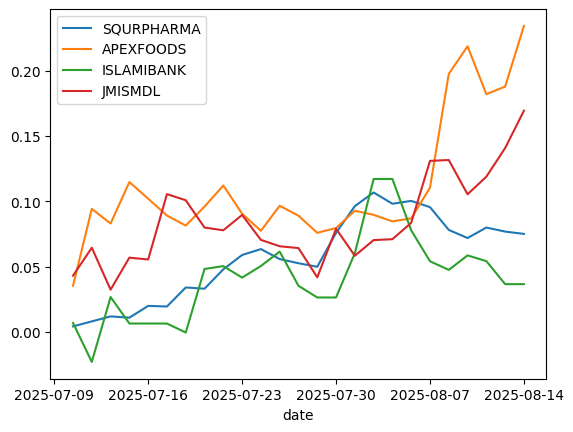

In [49]:
df[['SQURPHARMA','APEXFOODS','ISLAMIBANK','JMISMDL']].pct_change().cumsum().plot()